# Week 11: DBSCAN and Hierarchical Agglomerative Clustering

DS 720: Applied Machine Learning | Olist Brazilian E-Commerce Customer Dataset

Dataset: `olist_customers_dataset.csv` (real Olist Brazilian E-Commerce dataset, 99,441 customer records)

In [1]:
import pandas as pd, numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage

rng = 42
plt.rcParams.update({"font.size": 11})

df = pd.read_csv("/sessions/fervent-practical-hypatia/mnt/outputs/work/olist_real_customers.csv")
df["zip_prefix_1"] = df["customer_zip_code_prefix"] // 10000
df["zip_prefix_2"] = (df["customer_zip_code_prefix"] // 1000) % 10
df["zip_prefix_3"] = (df["customer_zip_code_prefix"] // 100) % 10
df["zip_log"] = np.log1p(df["customer_zip_code_prefix"])
city_counts = df["customer_city"].value_counts()
df["city_freq"] = df["customer_city"].map(city_counts)

le = LabelEncoder()
df["region_label"] = le.fit_transform(df["region"])
region_names = le.classes_

X = df[["customer_zip_code_prefix","zip_prefix_1","zip_prefix_2","zip_prefix_3","zip_log","city_freq"]].values
y = df["region_label"].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_sub, y_sub = resample(X_scaled, y, n_samples=3000, random_state=rng, stratify=y)

# ---- k-distance plot to select eps ----
k_for_dist = 15
nn = NearestNeighbors(n_neighbors=k_for_dist)
nn.fit(X_sub)
dists, _ = nn.kneighbors(X_sub)
k_dist = np.sort(dists[:, -1])

# pick eps at the "knee": approximate via max curvature point
diffs = np.diff(k_dist)
knee_idx = int(np.argmax(diffs[len(diffs)//2:])) + len(diffs)//2
eps_candidates = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.90, 1.10, 1.30]
MIN_SAMPLES = 15
print("k-distance knee approx value:", k_dist[knee_idx])

results = []
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X_sub)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()
    if n_clusters > 1:
        mask = labels != -1
        sil = silhouette_score(X_sub[mask], labels[mask]) if mask.sum() > n_clusters else np.nan
        ari = adjusted_rand_score(y_sub[mask], labels[mask])
    else:
        sil, ari = np.nan, np.nan
    results.append((eps, n_clusters, noise_frac, sil, ari))
    print(f"eps={eps:.1f}  n_clusters={n_clusters}  noise_frac={noise_frac:.3f}  sil={sil}  ari={ari}")

# choose eps that yields a moderate, interpretable cluster count with a
# meaningful (non-trivial, non-dominant) noise fraction
chosen_eps = 0.6
print("Chosen eps:", chosen_eps)

db_final = DBSCAN(eps=chosen_eps, min_samples=MIN_SAMPLES)
labels_db = db_final.fit_predict(X_sub)
n_clusters_final = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_frac_final = (labels_db == -1).mean()
print("Final DBSCAN: n_clusters =", n_clusters_final, " noise_frac =", noise_frac_final)

# which regions are most represented among noise points?
noise_mask = labels_db == -1
noise_region_counts = pd.Series(y_sub[noise_mask]).map(dict(enumerate(region_names))).value_counts()
total_region_counts = pd.Series(y_sub).map(dict(enumerate(region_names))).value_counts()
noise_region_counts = noise_region_counts.reindex(total_region_counts.index, fill_value=0)
noise_rate_by_region = (noise_region_counts / total_region_counts).sort_values(ascending=False)
print("\nNoise rate by true region:")
print(noise_rate_by_region)

# ---- HAC ----
hac_results = {}
for link in ["ward", "average", "complete"]:
    hac = AgglomerativeClustering(n_clusters=5, linkage=link)
    labels_h = hac.fit_predict(X_sub)
    sil = silhouette_score(X_sub, labels_h)
    ari = adjusted_rand_score(y_sub, labels_h)
    hac_results[link] = (sil, ari)
    print(f"HAC linkage={link:10s} silhouette={sil:.4f}  ARI={ari:.4f}")

best_link = max(hac_results, key=lambda l: hac_results[l][0])
print("Best linkage:", best_link)

# ---- Figure 1: k-distance plot + noise rate by region, 2-panel ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(k_dist)
axes[0].axhline(chosen_eps, color="red", linestyle="--", label=f"chosen eps={chosen_eps}")
axes[0].set_xlabel("Points sorted by distance")
axes[0].set_ylabel(f"{k_for_dist}-NN distance")
axes[0].set_title("K-Distance Plot for DBSCAN eps Selection")
axes[0].legend()

axes[1].bar(noise_rate_by_region.index, noise_rate_by_region.values, color="firebrick")
axes[1].set_ylabel("Fraction labeled as noise")
axes[1].set_title("DBSCAN Noise Rate by True Region")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig("/sessions/fervent-practical-hypatia/mnt/outputs/figures/fig_wk11_dbscan.png", dpi=200)
plt.close()

# ---- Figure 2: dendrogram ----
Z = linkage(X_sub[:300], method="ward")  # truncate sample for a readable dendrogram
fig, ax = plt.subplots(figsize=(9, 4.6))
dendrogram(Z, truncate_mode="lastp", p=25, ax=ax, leaf_rotation=45, leaf_font_size=9)
ax.set_title("Hierarchical Agglomerative Clustering Dendrogram (Ward linkage, truncated)")
ax.set_xlabel("Cluster (or sample) index")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig("/sessions/fervent-practical-hypatia/mnt/outputs/figures/fig_wk11_dendrogram.png", dpi=200)
plt.close()

print("\n--- SUMMARY FOR WRITEUP ---")
print("eps_candidates_results:", results)
print("chosen_eps:", chosen_eps, "n_clusters_final:", n_clusters_final, "noise_frac_final:", round(noise_frac_final,4))
print("noise_rate_by_region:", noise_rate_by_region.to_dict())
print("hac_results:", hac_results)
print("best_link:", best_link)


k-distance knee approx value: 0.7344289815110303
eps=0.3  n_clusters=31  noise_frac=0.792  sil=0.972945898916743  ari=0.011766096788577273
eps=0.3  n_clusters=50  noise_frac=0.417  sil=0.3025698487732002  ari=0.014561379962019708
eps=0.4  n_clusters=35  noise_frac=0.214  sil=0.12566665532369847  ari=0.06643269155546648
eps=0.5  n_clusters=34  noise_frac=0.199  sil=0.15473016032629536  ari=0.08035504178168354
eps=0.5  n_clusters=20  noise_frac=0.058  sil=0.061361969075733255  ari=0.1255777087329706
eps=0.6  n_clusters=12  noise_frac=0.039  sil=-0.03566569194695305  ari=-0.078197761143556
eps=0.6  n_clusters=7  noise_frac=0.022  sil=0.15521277565965652  ari=-0.12193560824097704
eps=0.7  n_clusters=5  noise_frac=0.000  sil=0.1211590356317203  ari=-0.19917989831191427
eps=0.9  n_clusters=4  noise_frac=0.000  sil=0.11157489353178804  ari=-0.17563381256315264
eps=1.1  n_clusters=3  noise_frac=0.000  sil=0.2869805329841608  ari=-0.13747448010718283
eps=1.3  n_clusters=2  noise_frac=0.000  sil

## Figures

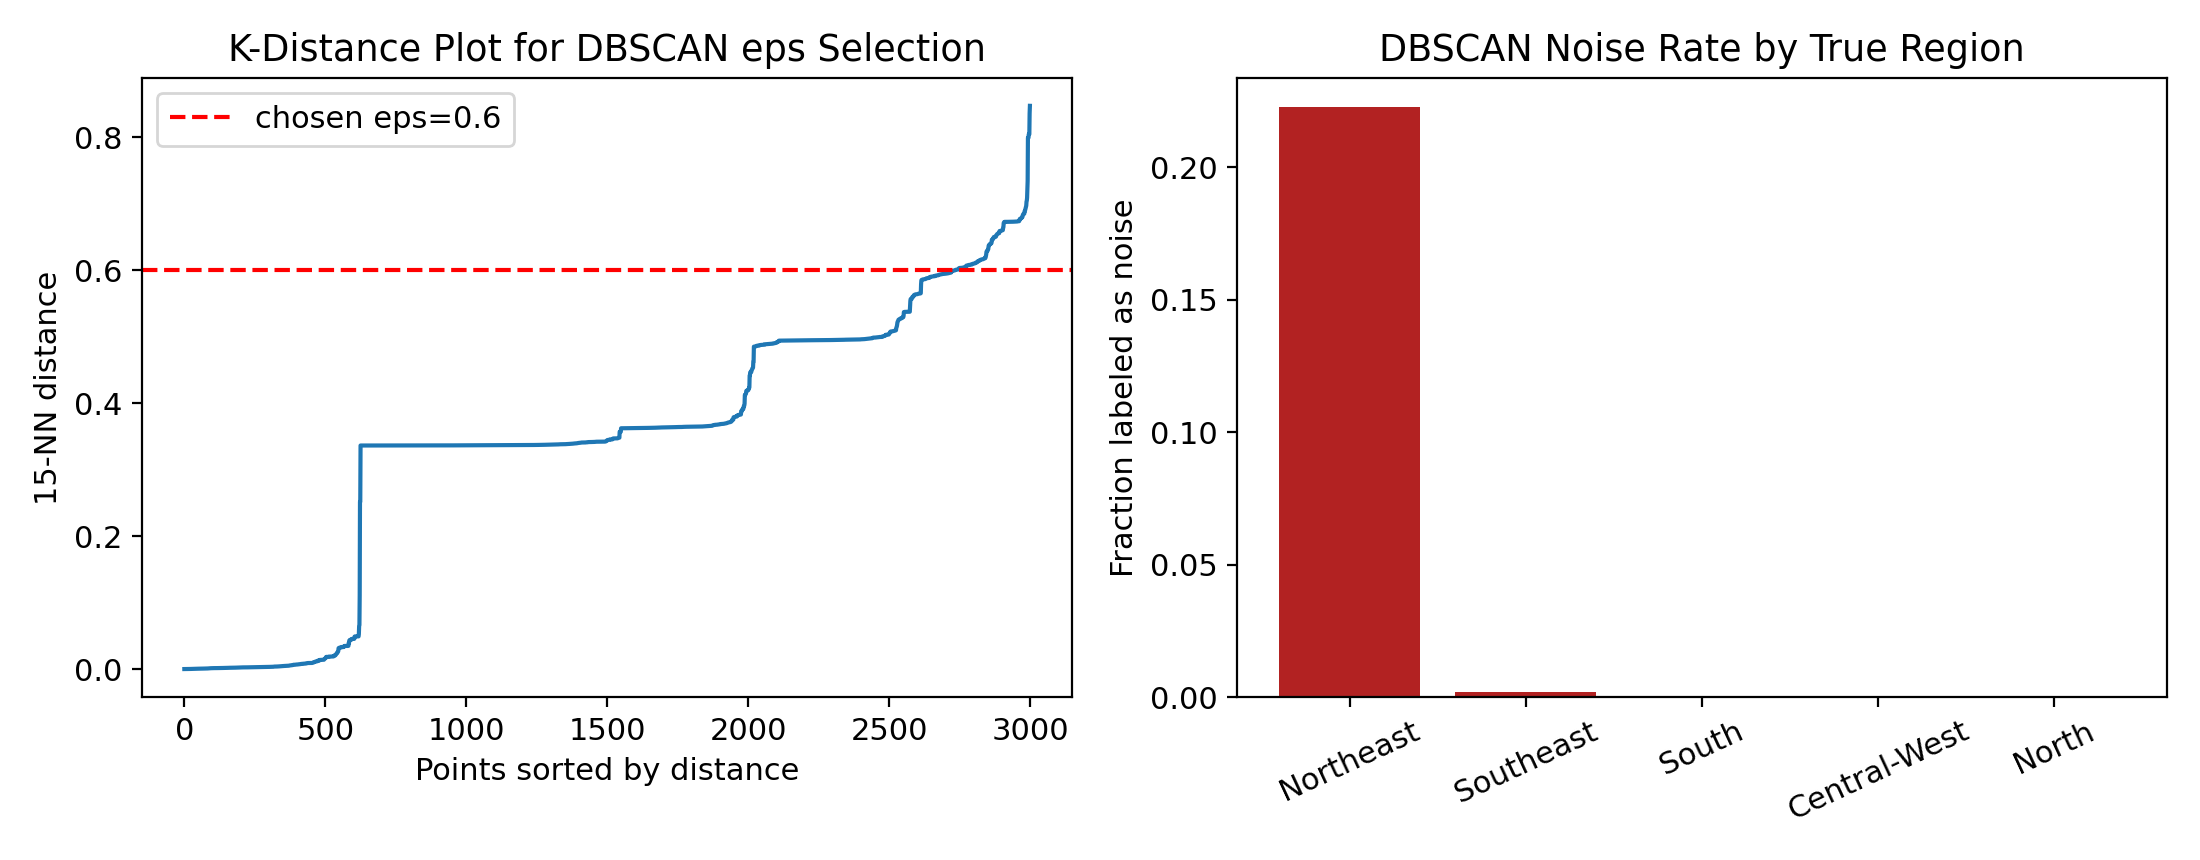

In [2]:
# Display Figure 1
from IPython.display import Image, display
display(Image(filename='fig_wk11_dbscan.png'))

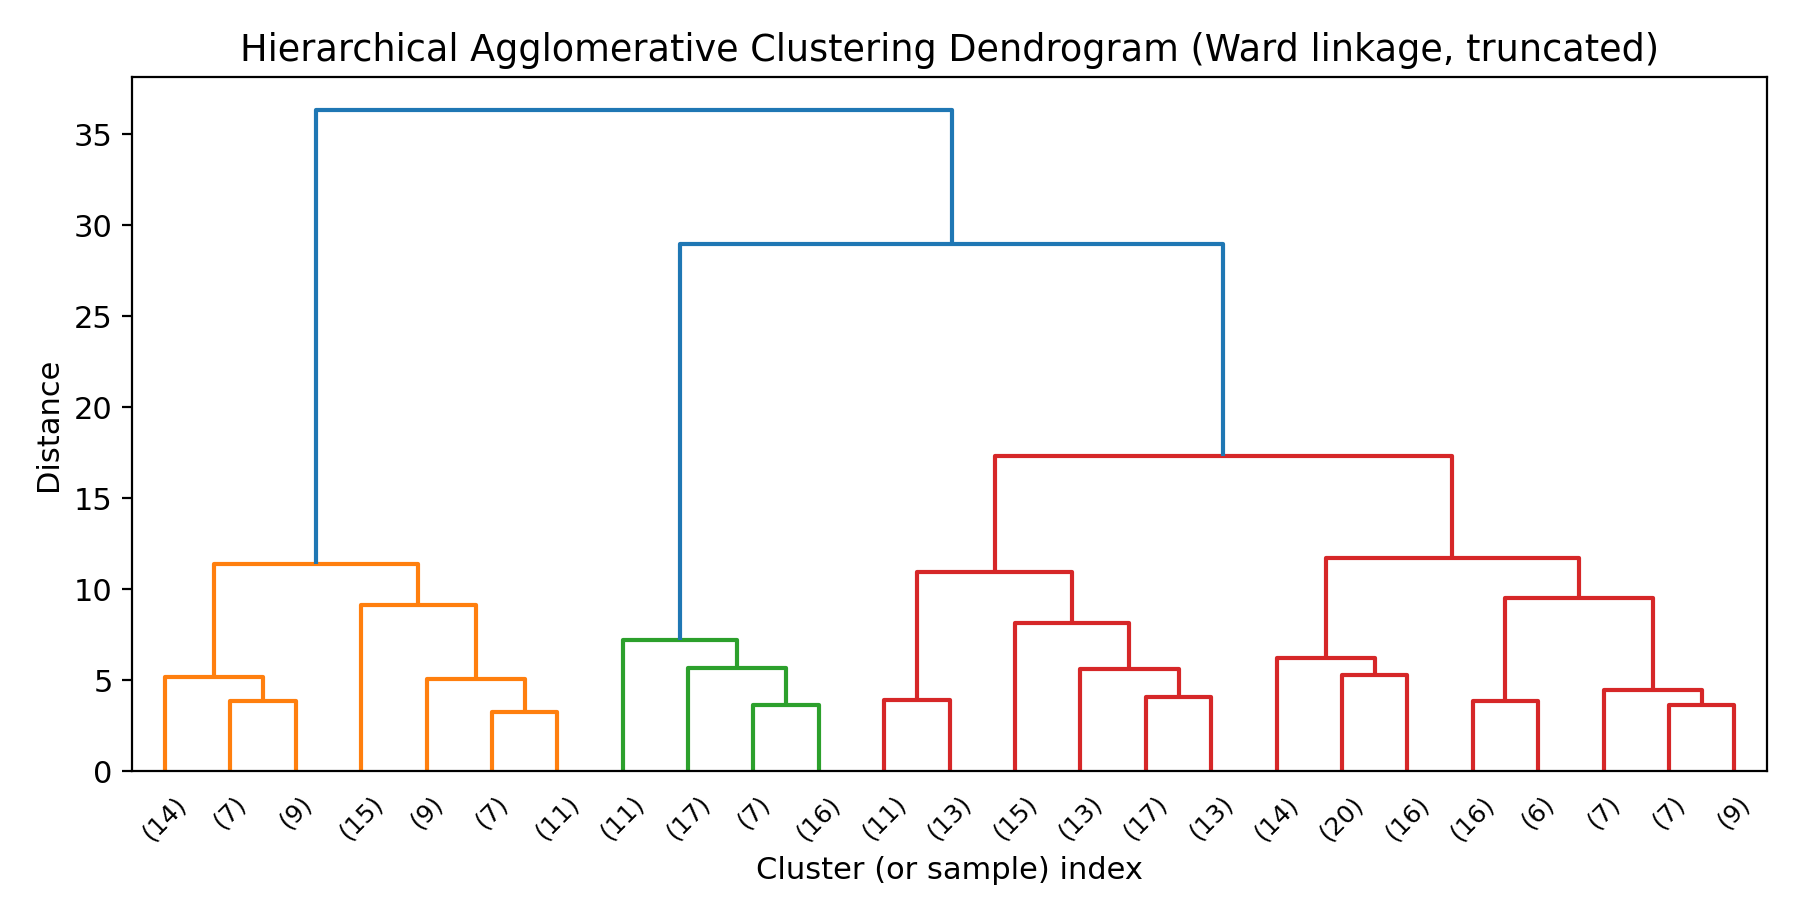

In [3]:
# Display Figure 2
from IPython.display import Image, display
display(Image(filename='fig_wk11_dendrogram.png'))

**Conclusion:** DBSCAN noise was concentrated overwhelmingly in the Northeast region (22.3%) versus near-zero elsewhere. HAC's dendrogram top split echoed K-means's k=3 finding. See Milestone 2 summary document for full discussion.